In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install shap joblib fastapi uvicorn


Defaulting to user installation because normal site-packages is not writeable

   ----- ---------------------------------- 1/7 [opentelemetry-api]
   ----------------- ---------------------- 3/7 [uvicorn]
   ---------------------- ----------------- 4/7 [starlette]
   ---------------------- ----------------- 4/7 [starlette]
   ---------------------------- ----------- 5/7 [shap]
   ---------------------------- ----------- 5/7 [shap]
   ---------------------------- ----------- 5/7 [shap]
   ---------------------------- ----------- 5/7 [shap]
   ---------------------------------- ----- 6/7 [fastapi]
   ---------------------------------------- 7/7 [fastapi]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import pandas as pd

df = pd.read_csv("Data/ai4i+2020+predictive+maintenance+dataset/ai4i2020.csv")



In [6]:
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

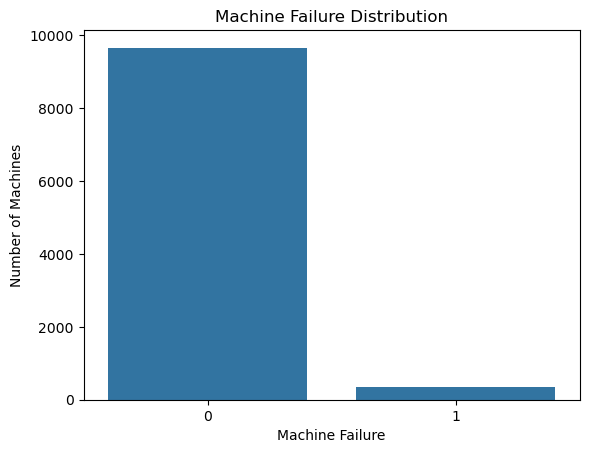

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Machine failure", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")
plt.show()

In [15]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [16]:
df = df.drop(columns=["UDI", "Product ID"])

In [17]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [18]:
features = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

In [19]:
target = 'Machine failure'

In [20]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


In [21]:
print(X.head())
print(y.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  
0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


In [22]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

print(X.head())
print(X.dtypes)


   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_L  Type_M  
0         42.8                0   False    True  
1         46.3                3    True   False  
2         49.4                5    True   False  
3         39.5                7    True   False  
4         40.0                9    True   False  
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type_L                        bool
Type_M                        bool
dtyp

In [23]:
print(X.isnull().sum())

Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Type_L                     0
Type_M                     0
dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 7)
X_test: (2000, 7)
y_train: (8000,)
y_test: (2000,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 7)
X_test_scaled shape: (2000, 7)


In [26]:
scaler.fit_transform(X_train)

array([[ 0.99891359,  0.60428162, -0.46060741, ..., -0.84399726,
        -1.23436595,  1.53620728],
       [-1.50519408, -1.15325984, -0.77557391, ...,  0.38226308,
        -1.23436595,  1.53620728],
       [ 0.49809206,  1.07746586, -1.00765448, ...,  0.46086951,
        -1.23436595,  1.53620728],
       ...,
       [ 0.14751698,  1.00986812, -0.41640159, ..., -1.23702942,
        -1.23436595, -0.65095382],
       [ 0.84866713,  0.80707487, -0.12353801, ...,  0.08355864,
         0.81013252, -0.65095382],
       [-0.65379747, -0.20689136, -0.42745305, ..., -1.63006158,
         0.81013252, -0.65095382]], shape=(8000, 7))

In [27]:
scaler.transform(X_test)

array([[ 0.24768129, -0.13929361, -1.07396322, ...,  0.71241009,
         0.81013252, -0.65095382],
       [ 1.85031019,  1.61824785, -0.14564092, ...,  0.42942694,
         0.81013252, -0.65095382],
       [ 1.24932436,  0.94227037,  0.10854256, ...,  1.59280213,
         0.81013252, -0.65095382],
       ...,
       [-0.95429039, -1.42365083, -0.51586469, ...,  0.20932893,
        -1.23436595,  1.53620728],
       [ 1.1992422 ,  1.28025911, -0.64848216, ...,  1.35698283,
        -1.23436595,  1.53620728],
       [-1.0544547 , -0.6800756 ,  2.37961675, ..., -1.11125913,
        -1.23436595,  1.53620728]], shape=(2000, 7))

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [29]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
print("Actual:", y_test.values[:20])
print("Predicted:", y_pred[:20])

Actual: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
Predicted: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1928    4]
 [  61    7]]

Accuracy: 0.9675

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [32]:
model_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Prediction completed!")

Prediction completed!


In [33]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(cm_balanced)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Confusion Matrix:
[[1593  339]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest prediction completed!")

Random Forest prediction completed!


In [35]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Confusion Matrix:
[[1929    3]
 [  36   32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.47      0.62        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000



In [36]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
3              Torque [Nm]    0.311137
2   Rotational speed [rpm]    0.290771
4          Tool wear [min]    0.207939
0      Air temperature [K]    0.105084
1  Process temperature [K]    0.067814
5                   Type_L    0.009703
6                   Type_M    0.007552


In [37]:
rf_probability = rf_model.predict_proba(X_test)[:, 1]

print(rf_probability[:20])

[0.145 0.    0.06  0.005 0.075 0.    0.015 0.    0.    0.055 0.    0.01
 0.    0.    0.    0.    0.    0.195 0.    0.   ]


In [38]:
for actual, prediction, probability in zip(
    y_test.values[:20],
    rf_pred[:20],
    rf_probability[:20]
):
    print(
        f"Actual: {actual}, "
        f"Predicted: {prediction}, "
        f"Failure Probability: {probability:.2%}"
    )

Actual: 0, Predicted: 0, Failure Probability: 14.50%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 6.00%
Actual: 0, Predicted: 0, Failure Probability: 0.50%
Actual: 0, Predicted: 0, Failure Probability: 7.50%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 1.50%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 5.50%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 1.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 1, Predicted: 0, Failure Probability: 19.50%
Actual: 0, Predicted: 0, Failure Probability: 0.00%
Actual: 0,

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:

    predictions = (rf_probability >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.10 | Precision: 0.41 | Recall: 0.87 | F1: 0.56
Threshold: 0.15 | Precision: 0.51 | Recall: 0.84 | F1: 0.63
Threshold: 0.20 | Precision: 0.60 | Recall: 0.78 | F1: 0.68
Threshold: 0.25 | Precision: 0.72 | Recall: 0.75 | F1: 0.73
Threshold: 0.30 | Precision: 0.79 | Recall: 0.72 | F1: 0.75
Threshold: 0.35 | Precision: 0.83 | Recall: 0.66 | F1: 0.74
Threshold: 0.40 | Precision: 0.84 | Recall: 0.63 | F1: 0.72
Threshold: 0.45 | Precision: 0.89 | Recall: 0.57 | F1: 0.70
Threshold: 0.50 | Precision: 0.91 | Recall: 0.47 | F1: 0.62


In [40]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_new.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (6400, 7)
Validation: (1600, 7)
Test: (2000, 7)


In [41]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_new, y_train_new)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
val_probability = rf_final.predict_proba(X_val)[:, 1]

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:

    val_pred = (val_probability >= threshold).astype(int)

    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.10 | Precision: 0.38 | Recall: 0.81 | F1: 0.51
Threshold: 0.15 | Precision: 0.47 | Recall: 0.78 | F1: 0.58
Threshold: 0.20 | Precision: 0.58 | Recall: 0.74 | F1: 0.65
Threshold: 0.25 | Precision: 0.63 | Recall: 0.69 | F1: 0.65
Threshold: 0.30 | Precision: 0.66 | Recall: 0.65 | F1: 0.65
Threshold: 0.35 | Precision: 0.72 | Recall: 0.61 | F1: 0.66
Threshold: 0.40 | Precision: 0.82 | Recall: 0.50 | F1: 0.62
Threshold: 0.45 | Precision: 0.84 | Recall: 0.50 | F1: 0.63
Threshold: 0.50 | Precision: 0.89 | Recall: 0.46 | F1: 0.61


In [44]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Test set probabilities
test_probability = rf_final.predict_proba(X_test)[:, 1]

# Selected threshold from validation
final_threshold = 0.35

# Final predictions
test_pred = (test_probability >= final_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, test_pred, zero_division=0))

print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1 Score:", f1_score(y_test, test_pred))

Confusion Matrix:
[[1917   15]
 [  29   39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.57      0.64        68

    accuracy                           0.98      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.98      0.98      0.98      2000

Precision: 0.7222222222222222
Recall: 0.5735294117647058
F1 Score: 0.639344262295082


In [45]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, test_probability)
pr_auc = average_precision_score(y_test, test_probability)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9560421994884911
PR-AUC: 0.736774682201514


In [46]:
import pandas as pd

def predict_machine_failure(
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear
):
    
    # Create input dataframe
    input_data = pd.DataFrame({
        'Type': [machine_type],
        'Air temperature [K]': [air_temperature],
        'Process temperature [K]': [process_temperature],
        'Rotational speed [rpm]': [rotational_speed],
        'Torque [Nm]': [torque],
        'Tool wear [min]': [tool_wear]
    })
    
    # One-hot encoding
    input_data = pd.get_dummies(
        input_data,
        columns=['Type'],
        drop_first=True
    )
    
    # Make sure input has exactly the same columns as training data
    input_data = input_data.reindex(
        columns=X_train.columns,
        fill_value=0
    )
    
    # Failure probability
    probability = rf_final.predict_proba(input_data)[0][1]
    
    # Apply selected threshold
    prediction = int(probability >= final_threshold)
    
    return probability, prediction

In [47]:
probability, prediction = predict_machine_failure(
    machine_type='L',
    air_temperature=300,
    process_temperature=310,
    rotational_speed=1500,
    torque=45,
    tool_wear=180
)

print("Failure Probability:", round(probability * 100, 2), "%")
print("Prediction:", prediction)

Failure Probability: 0.0 %
Prediction: 0


In [48]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [50]:
import shap

In [52]:
import shap

explainer = shap.TreeExplainer(rf_final)

shap_values = explainer.shap_values(X_test)

print("SHAP calculation completed")

SHAP calculation completed


In [53]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else len(shap_values))
print("SHAP is working")

<class 'numpy.ndarray'>
(2000, 7, 2)
SHAP is working


In [54]:
# SHAP values for failure class
shap_failure = shap_values[:, :, 1]

print("SHAP failure shape:", shap_failure.shape)

SHAP failure shape: (2000, 7)


In [55]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Absolute SHAP': np.abs(shap_failure).mean(axis=0)
}).sort_values(
    by='Mean Absolute SHAP',
    ascending=False
)

print(shap_importance)

                   Feature  Mean Absolute SHAP
3              Torque [Nm]            0.159787
2   Rotational speed [rpm]            0.132454
4          Tool wear [min]            0.090877
0      Air temperature [K]            0.080638
1  Process temperature [K]            0.040100
5                   Type_L            0.009067
6                   Type_M            0.005063


In [56]:
sample_index = 0

print("Machine input:")
print(X_test.iloc[sample_index])

print("\nActual:", y_test.iloc[sample_index])
print("Predicted:", test_pred[sample_index])
print("Failure Probability:", round(test_probability[sample_index] * 100, 2), "%")

Machine input:
Air temperature [K]        300.5
Process temperature [K]    309.8
Rotational speed [rpm]      1345
Torque [Nm]                 62.7
Tool wear [min]              153
Type_L                      True
Type_M                     False
Name: 2997, dtype: object

Actual: 0
Predicted: 0
Failure Probability: 17.5 %


In [57]:
sample_shap = shap_failure[sample_index]

explanation = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP Value': sample_shap
}).sort_values(
    by='SHAP Value',
    key=abs,
    ascending=False
)

print(explanation)

                   Feature  SHAP Value
0      Air temperature [K]   -0.209362
4          Tool wear [min]   -0.182695
3              Torque [Nm]    0.122994
1  Process temperature [K]   -0.052898
2   Rotational speed [rpm]    0.009784
5                   Type_L   -0.008419
6                   Type_M   -0.002368


In [58]:
import pandas as pd
import numpy as np

def predict_and_explain(
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear
):
    
    # -----------------------------
    # 1. Create input
    # -----------------------------
    input_data = pd.DataFrame({
        'Type': [machine_type],
        'Air temperature [K]': [air_temperature],
        'Process temperature [K]': [process_temperature],
        'Rotational speed [rpm]': [rotational_speed],
        'Torque [Nm]': [torque],
        'Tool wear [min]': [tool_wear]
    })

    # -----------------------------
    # 2. Encode Type
    # -----------------------------
    input_data = pd.get_dummies(
        input_data,
        columns=['Type'],
        drop_first=True
    )

    # Same columns as training data
    input_data = input_data.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    # -----------------------------
    # 3. Prediction
    # -----------------------------
    probability = rf_final.predict_proba(input_data)[0][1]

    prediction = int(
        probability >= final_threshold
    )

    # -----------------------------
    # 4. SHAP explanation
    # -----------------------------
    shap_result = explainer.shap_values(input_data)

    # Failure class SHAP values
    if isinstance(shap_result, list):
        sample_shap = shap_result[1][0]
    else:
        sample_shap = shap_result[0, :, 1]

    # -----------------------------
    # 5. Create explanation table
    # -----------------------------
    explanation = pd.DataFrame({
        'Feature': X_train.columns,
        'SHAP Value': sample_shap
    })

    explanation['Absolute SHAP'] = (
        explanation['SHAP Value'].abs()
    )

    explanation = explanation.sort_values(
        by='Absolute SHAP',
        ascending=False
    )

    # -----------------------------
    # 6. Separate factors
    # -----------------------------
    failure_factors = explanation[
        explanation['SHAP Value'] > 0
    ].head(3)

    normal_factors = explanation[
        explanation['SHAP Value'] < 0
    ].head(3)

    # -----------------------------
    # 7. Print report
    # -----------------------------
    print("=" * 45)
    print("        MACHINE HEALTH REPORT")
    print("=" * 45)

    print(
        f"Failure Probability: "
        f"{probability * 100:.2f}%"
    )

    if prediction == 1:
        print("Status: FAILURE RISK")
    else:
        print("Status: NORMAL")

    print("\nTop Failure Factors:")

    if len(failure_factors) == 0:
        print("No strong failure-direction factors.")
    else:
        for _, row in failure_factors.iterrows():
            print(
                f"- {row['Feature']}: "
                f"{row['SHAP Value']:.4f}"
            )

    print("\nFactors Supporting Normal:")

    if len(normal_factors) == 0:
        print("No strong normal-direction factors.")
    else:
        for _, row in normal_factors.iterrows():
            print(
                f"- {row['Feature']}: "
                f"{row['SHAP Value']:.4f}"
            )

    print("=" * 45)

    return {
        'failure_probability': probability,
        'prediction': prediction,
        'explanation': explanation
    }

In [59]:
result = predict_and_explain(
    machine_type='L',
    air_temperature=300,
    process_temperature=310,
    rotational_speed=1500,
    torque=45,
    tool_wear=180
)

        MACHINE HEALTH REPORT
Failure Probability: 0.00%
Status: NORMAL

Top Failure Factors:
No strong failure-direction factors.

Factors Supporting Normal:
- Torque [Nm]: -0.1487
- Rotational speed [rpm]: -0.1464
- Air temperature [K]: -0.0884


In [60]:
import joblib

joblib.dump(rf_final, "indusmind_machine_failure_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [61]:
joblib.dump(final_threshold, "indusmind_threshold.pkl")

print("Threshold saved successfully!")

Threshold saved successfully!


In [62]:
joblib.dump(
    list(X_train.columns),
    "indusmind_features.pkl"
)

print("Features saved successfully!")

Features saved successfully!


In [63]:
import os

print(os.path.exists("indusmind_machine_failure_model.pkl"))
print(os.path.exists("indusmind_threshold.pkl"))
print(os.path.exists("indusmind_features.pkl"))

True
True
True
